In [1]:
import pandas as pd
df = pd.read_csv("IMDB Dataset.csv")
print(df.shape)
print(df.head())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive


In [3]:
# Missing values check
print("Missing values:\n", df.isnull().sum())

# Duplicate rows check
print("\nDuplicate rows:", df.duplicated().sum())

# Sentiment distribution
print("\nSentiment count:\n", df['sentiment'].value_counts())

Missing values:
 review       0
sentiment    0
dtype: int64

Duplicate rows: 418

Sentiment count:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
# Duplicates remove karo
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

# HTML tags remove karo — <br /> wale
import re
df['review'] = df['review'].apply(lambda x: re.sub('<.*?>', '', x))

# Lowercase karo
df['review'] = df['review'].str.lower()

print("\nCleaned review example:")
print(df['review'][0][:200])

Shape after removing duplicates: (49582, 2)

Cleaned review example:
one of the other reviewers has mentioned that after watching just 1 oz episode you'll be hooked. they are right, as this is exactly what happened with me.the first thing that struck me about oz was it


In [7]:
import sqlite3

# Database banao
conn = sqlite3.connect("imdb_reviews.db")

# DataFrame ko database mein save karo
df.to_sql("reviews", conn, if_exists="replace", index=False)

print("✅ Database created successfully!")
print("Total rows saved:", pd.read_sql("SELECT COUNT(*) FROM reviews", conn).values[0][0])

✅ Database created successfully!
Total rows saved: 49582


In [9]:
# Query 1: Positive vs Negative count
print("📊 Sentiment Distribution:")
print(pd.read_sql("SELECT sentiment, COUNT(*) as count FROM reviews GROUP BY sentiment", conn))

# Query 2: Average review length
print("\n📏 Average Review Length:")
print(pd.read_sql("SELECT sentiment, AVG(LENGTH(review)) as avg_length FROM reviews GROUP BY sentiment", conn))

# Query 3: Longest reviews
print("\n📝 Top 5 Longest Reviews:")
print(pd.read_sql("SELECT sentiment, LENGTH(review) as length FROM reviews ORDER BY length DESC LIMIT 5", conn))

# Query 4: Shortest reviews
print("\n📝 Top 5 Shortest Reviews:")
print(pd.read_sql("SELECT sentiment, LENGTH(review) as length FROM reviews ORDER BY length ASC LIMIT 5", conn))

📊 Sentiment Distribution:
  sentiment  count
0  negative  24698
1  positive  24884

📏 Average Review Length:
  sentiment   avg_length
0  negative  1269.731071
1  positive  1302.729425

📝 Top 5 Longest Reviews:
  sentiment  length
0  positive   13584
1  positive   12690
2  positive   12472
3  positive   11961
4  positive   10249

📝 Top 5 Shortest Reviews:
  sentiment  length
0  negative      32
1  negative      41
2  negative      49
3  negative      51
4  negative      52


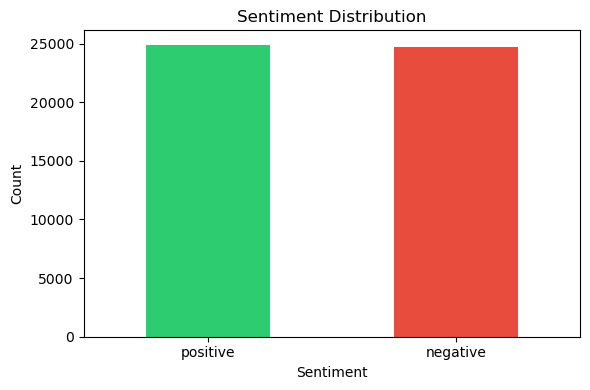

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: Sentiment Distribution
plt.figure(figsize=(6,4))
df['sentiment'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

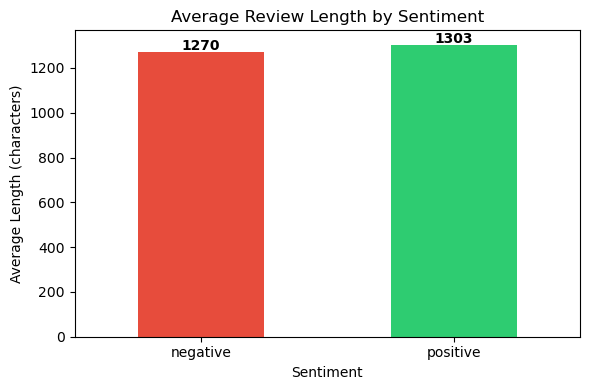

In [15]:
# Chart 2: Average Review Length by Sentiment
avg_length = df.groupby('sentiment')['review_length'].mean()

plt.figure(figsize=(6,4))
avg_length.plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Average Review Length by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average Length (characters)')
plt.xticks(rotation=0)

# Exact values upar dikhao
for i, v in enumerate(avg_length):
    plt.text(i, v + 10, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [17]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


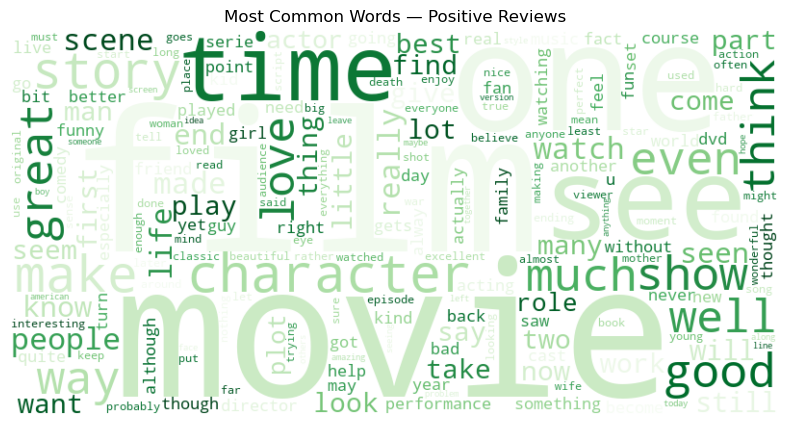

In [19]:
from wordcloud import WordCloud

# Positive reviews word cloud
positive_text = ' '.join(df[df['sentiment']=='positive']['review'])

plt.figure(figsize=(10,5))
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      colormap='Greens').generate(positive_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — Positive Reviews')
plt.show()

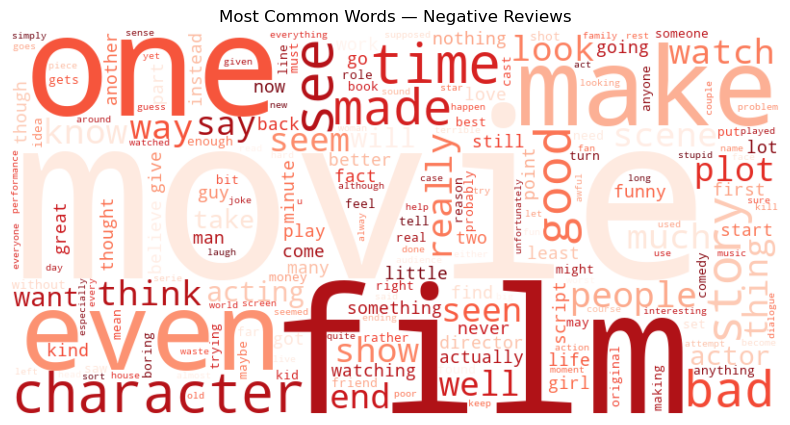

In [21]:
# Negative reviews word cloud
negative_text = ' '.join(df[df['sentiment']=='negative']['review'])

plt.figure(figsize=(10,5))
wordcloud_neg = WordCloud(width=800, height=400,
                          background_color='white',
                          colormap='Reds').generate(negative_text)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — Negative Reviews')
plt.show()

In [23]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Stopwords remove karo
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df['review_clean'] = df['review'].apply(clean_text)
print("✅ Stopwords removed!")
print("\nExample:")
print(df['review_clean'][0][:200])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


✅ Stopwords removed!

Example:
one reviewers mentioned watching 1 oz episode hooked. right, exactly happened me.the first thing struck oz brutality unflinching scenes violence, set right word go. trust me, show faint hearted timid.


In [25]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# X aur y define karo
X = df['review_clean']
y = df['sentiment']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF done!")
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

✅ TF-IDF done!
Training shape: (39665, 5000)
Testing shape: (9917, 5000)


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"✅ Logistic Regression Accuracy: {lr_acc:.4f}")

# Model 2: Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
nb_pred = nb.predict(X_test_tfidf)
nb_acc = accuracy_score(y_test, nb_pred)
print(f"✅ Naive Bayes Accuracy: {nb_acc:.4f}")

# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_tfidf, y_train)
rf_pred = rf.predict(X_test_tfidf)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest Accuracy: {rf_acc:.4f}")

✅ Logistic Regression Accuracy: 0.8900
✅ Naive Bayes Accuracy: 0.8534
✅ Random Forest Accuracy: 0.8377


📊 Classification Report:
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4939
    positive       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



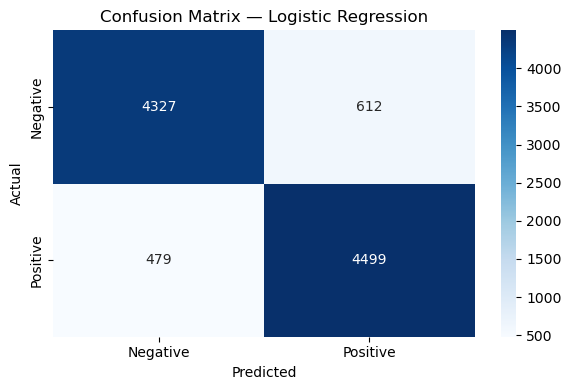

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Best model — Logistic Regression ka detailed report
print("📊 Classification Report:")
print(classification_report(y_test, lr_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, lr_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [33]:
import pickle

# Model aur TF-IDF save karo
with open('model.pkl', 'wb') as f:
    pickle.dump(lr, f)

with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model saved!")
print("✅ TF-IDF saved!")

✅ Model saved!
✅ TF-IDF saved!
